In [6]:
from datasets import load_dataset
import collections
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np
from tqdm import tqdm
import os
import sys
sys.path.append("..")
from config import DATA_DIR, RESULTS_DIR

In [7]:
dataset = load_dataset("google/speech_commands", "v0.01")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 51093
    })
    validation: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 6799
    })
    test: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 3081
    })
})


In [ ]:
print(dataset.keys())
print(dataset["validation"].features)
print(dataset["validation"][0])
print(f"Label names: {dataset['train'].features['label'].names}")

dict_keys(['train', 'validation', 'test'])
{'file': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=16000, mono=True, decode=True, id=None), 'label': ClassLabel(names=['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go', 'zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'bed', 'bird', 'cat', 'dog', 'happy', 'house', 'marvin', 'sheila', 'tree', 'wow', '_silence_'], id=None), 'is_unknown': Value(dtype='bool', id=None), 'speaker_id': Value(dtype='string', id=None), 'utterance_id': Value(dtype='int8', id=None)}
{'file': 'bed/2ce7534c_nohash_1.wav', 'audio': {'path': 'bed/2ce7534c_nohash_1.wav', 'array': array([ 0.00079346,  0.00247192,  0.00186157, ...,  0.00579834,
       -0.00418091,  0.00326538], shape=(16000,)), 'sampling_rate': 16000}, 'label': 20, 'is_unknown': True, 'speaker_id': '2ce7534c', 'utterance_id': 1}
Label names: ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go', 'zero', 'one', 'two', 'three'

In [8]:
label_names = dataset["train"].features["label"].names

DIGIT_LABELS = ['zero','one','two','three','four','five','six','seven','eight','nine']

# BASELINE — 10 classes only (keep as original)
digit_to_idx = {label_names.index(d): i for i, d in enumerate(DIGIT_LABELS)}
idx_to_digit = {i: d for i, d in enumerate(DIGIT_LABELS)}

# EXTENDED — 11 classes for augmented experiment
EXTENDED_LABELS = DIGIT_LABELS + ['_silence_']
digit_to_idx_11 = {label_names.index(d): i for i, d in enumerate(EXTENDED_LABELS)}
idx_to_digit_11 = {i: d for i, d in enumerate(EXTENDED_LABELS)}

print("Baseline label mapping (10 classes):")
for original_id, new_id in digit_to_idx.items():
    print(f"  {original_id} ({label_names[original_id]}) -> {new_id}")

print("\nExtended label mapping (11 classes):")
for original_id, new_id in digit_to_idx_11.items():
    print(f"  {original_id} ({label_names[original_id]}) -> {new_id}")

Baseline label mapping (10 classes):
  10 (zero) -> 0
  11 (one) -> 1
  12 (two) -> 2
  13 (three) -> 3
  14 (four) -> 4
  15 (five) -> 5
  16 (six) -> 6
  17 (seven) -> 7
  18 (eight) -> 8
  19 (nine) -> 9

Extended label mapping (11 classes):
  10 (zero) -> 0
  11 (one) -> 1
  12 (two) -> 2
  13 (three) -> 3
  14 (four) -> 4
  15 (five) -> 5
  16 (six) -> 6
  17 (seven) -> 7
  18 (eight) -> 8
  19 (nine) -> 9
  30 (_silence_) -> 10


In [9]:

digit_ids = set(digit_to_idx.keys())

def is_digit(example):
    return example["label"] in digit_ids

dataset_digits = dataset.filter(is_digit)
print(dataset_digits)


DatasetDict({
    train: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 18620
    })
    validation: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 2494
    })
    test: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 160
    })
})


In [33]:
silence_original_id = label_names.index('_silence_')

silence_clips_train = []
silence_clips_val = []
silence_clips_test = []

for example in dataset["train"]:
    if example["label"] == silence_original_id:
        silence_clips_train.append(
            np.array(example["audio"]["array"], dtype=np.float32)
        )

for example in dataset["validation"]:
    if example["label"] == silence_original_id:
        silence_clips_val.append(
            np.array(example["audio"]["array"], dtype=np.float32)
        )

for example in dataset["test"]:
    if example["label"] == silence_original_id:
        silence_clips_test.append(
            np.array(example["audio"]["array"], dtype=np.float32)
        )

print(f"Silence clips — train: {len(silence_clips_train)}, "
      f"val: {len(silence_clips_val)}, test: {len(silence_clips_test)}")

for i, clip in enumerate(silence_clips_train):
    print(f"  Train clip {i+1}: {len(clip)/16000:.1f}s")

Silence clips — train: 5, val: 1, test: 257
  Train clip 1: 61.8s
  Train clip 2: 60.0s
  Train clip 3: 61.3s
  Train clip 4: 60.0s
  Train clip 5: 95.2s


In [34]:
print("Train silence clip lengths:")
for i, clip in enumerate(silence_clips_train):
    print(f"  Clip {i+1}: {len(clip)/16000:.1f}s")

print("\nValidation silence clip lengths:")
for i, clip in enumerate(silence_clips_val):
    print(f"  Clip {i+1}: {len(clip)/16000:.1f}s")

print("\nTest silence clip lengths:")
for i, clip in enumerate(silence_clips_test):
    print(f"  Clip {i+1}: {len(clip)/16000:.1f}s")

Train silence clip lengths:
  Clip 1: 61.8s
  Clip 2: 60.0s
  Clip 3: 61.3s
  Clip 4: 60.0s
  Clip 5: 95.2s

Validation silence clip lengths:
  Clip 1: 61.2s

Test silence clip lengths:
  Clip 1: 1.0s
  Clip 2: 1.0s
  Clip 3: 1.0s
  Clip 4: 1.0s
  Clip 5: 1.0s
  Clip 6: 1.0s
  Clip 7: 1.0s
  Clip 8: 1.0s
  Clip 9: 1.0s
  Clip 10: 1.0s
  Clip 11: 1.0s
  Clip 12: 1.0s
  Clip 13: 1.0s
  Clip 14: 1.0s
  Clip 15: 1.0s
  Clip 16: 1.0s
  Clip 17: 1.0s
  Clip 18: 1.0s
  Clip 19: 1.0s
  Clip 20: 1.0s
  Clip 21: 1.0s
  Clip 22: 1.0s
  Clip 23: 1.0s
  Clip 24: 1.0s
  Clip 25: 1.0s
  Clip 26: 1.0s
  Clip 27: 1.0s
  Clip 28: 1.0s
  Clip 29: 1.0s
  Clip 30: 1.0s
  Clip 31: 1.0s
  Clip 32: 1.0s
  Clip 33: 1.0s
  Clip 34: 1.0s
  Clip 35: 1.0s
  Clip 36: 1.0s
  Clip 37: 1.0s
  Clip 38: 1.0s
  Clip 39: 1.0s
  Clip 40: 1.0s
  Clip 41: 1.0s
  Clip 42: 1.0s
  Clip 43: 1.0s
  Clip 44: 1.0s
  Clip 45: 1.0s
  Clip 46: 1.0s
  Clip 47: 1.0s
  Clip 48: 1.0s
  Clip 49: 1.0s
  Clip 50: 1.0s
  Clip 51: 1.0s
  Clip 

Checking class inbalances after filtering

In [35]:
print("digit_ids:", digit_ids)

test_label_counts = collections.Counter(dataset_digits["train"]["label"])
print("\nAll labels in test set:")
for label_id, count in sorted(test_label_counts.items()):
    print(f"  {label_id} ({label_names[label_id]}): {count}")
    

digit_ids: {10, 11, 12, 13, 14, 15, 16, 17, 18, 19}

All labels in test set:
  10 (zero): 1866
  11 (one): 1892
  12 (two): 1873
  13 (three): 1841
  14 (four): 1839
  15 (five): 1844
  16 (six): 1863
  17 (seven): 1875
  18 (eight): 1852
  19 (nine): 1875


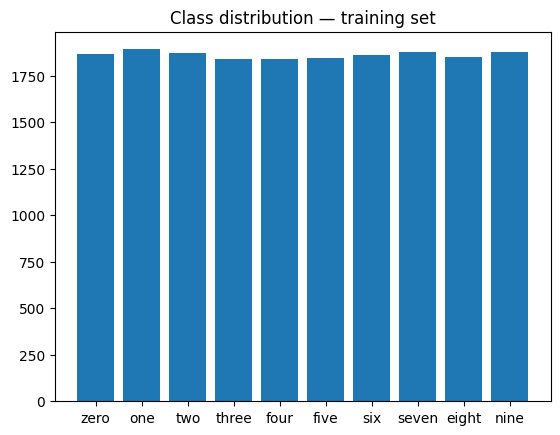

In [36]:
counts = collections.Counter(dataset_digits["train"]["label"])
plt.bar([label_names[k] for k in sorted(counts)], [counts[k] for k in sorted(counts)])
plt.title("Class distribution — training set")
plt.savefig("class_balance.png")

{'file': 'eight/8f4c551f_nohash_3.wav', 'audio': {'path': 'eight/8f4c551f_nohash_3.wav', 'array': array([ 0.00015259,  0.00030518,  0.00030518, ..., -0.00027466,
       -0.00027466, -0.00036621], shape=(16000,)), 'sampling_rate': 16000}, 'label': 18, 'is_unknown': True, 'speaker_id': '8f4c551f', 'utterance_id': 3}
Audio shape: (16000,), Label: eight (eight)


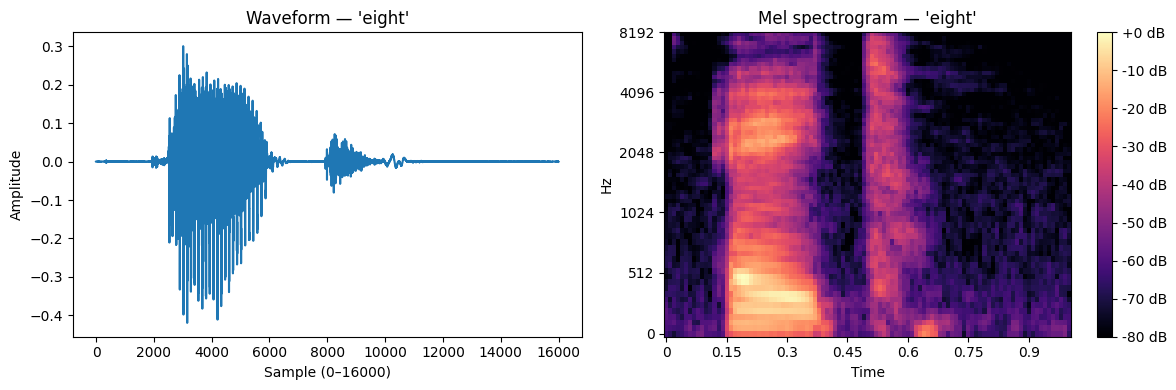

In [37]:
def compute_mel(audio_array, sr=16000, for_model=False):
    # Pad or truncate if needed
    target_length = 16000
    if len(audio_array) < target_length:
        audio_array = np.pad(audio_array, (0, target_length - len(audio_array)))
    else:
        audio_array = audio_array[:target_length]

    # Core computation — same either way
    mel = librosa.feature.melspectrogram(
        y=audio_array, sr=sr, n_mels=64, n_fft=400, hop_length=160
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    if for_model:
        # Normalize and add channel dimension for CNN
        mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
        return mel_norm[..., np.newaxis]  # (64, 101, 1)
    else:
        # Return raw dB values for visualization
        return mel_db  # (64, 101)

sample = dataset_digits["train"][0]
print(sample)
audio = np.array(sample["audio"]["array"], dtype=np.float32)
label = dataset_digits["train"].features["label"].names[sample["label"]]
word = label_names[sample["label"]]
print(f"Audio shape: {audio.shape}, Label: {label} ({word})")
mel = compute_mel(audio)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left — raw waveform
axes[0].plot(audio)
axes[0].set_title(f"Waveform — '{word}'")
axes[0].set_xlabel("Sample (0–16000)")
axes[0].set_ylabel("Amplitude")

# Right — mel spectrogram

img = librosa.display.specshow(
    mel, sr=16000, hop_length=160,
    x_axis='time', y_axis='mel',
    ax=axes[1]
)
axes[1].set_title(f"Mel spectrogram — '{word}'")
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.savefig("waveform_vs_spectrogram.png")
plt.show()

Preprocessing functions for both mel spectrograms and MFCC for comparison

audio_to_mel and compute_mel are almost the same, in compute_mel we need to extract audio data and takes in a raw numpy array, this can be used for model training if sat to true, but the purpose is for visualization. Its more flexible.
audio_to_mel takes a HuggingFace dictionary directly and does the job for us, this always produces model-ready output

In [38]:
def audio_to_mel(example):
    audio = np.array(example["audio"]["array"], dtype=np.float32)
    sr = example["audio"]["sampling_rate"]
    
    # Pad or truncate to exactly 1 second
    target_length = 16000
    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)))
    else:
        audio = audio[:target_length]
    
    # Mel spectrogram
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=64, n_fft=400, hop_length=160
    )
    
    # Convert to decibels
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    # Normalize to [0, 1]
    mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    
    # Add channel dimension (64, 101) → (64, 101, 1)
    return mel_norm[..., np.newaxis]


def audio_to_mfcc(example):
    audio = np.array(example["audio"]["array"], dtype=np.float32)
    sr = example["audio"]["sampling_rate"]
    
    # Pad or truncate to exactly 1 second
    target_length = 16000
    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)))
    else:
        audio = audio[:target_length]
    
    # MFCC
    mfcc = librosa.feature.mfcc(
        y=audio, sr=sr, n_mfcc=40, n_fft=400, hop_length=160
    )
    
    # Normalize each coefficient independently
    mfcc = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (mfcc.std(axis=1, keepdims=True) + 1e-8)
    
    # Add channel dimension (40, 101) → (40, 101, 1)
    return mfcc[..., np.newaxis]

Remapping to include only the used labels (10 numbers) for matching 10 outputs that the model will have

In [39]:
def preprocess_for_training(example, use_mfcc=False):
    # Get spectrogram
    if use_mfcc:
        features = audio_to_mfcc(example)
    else:
        features = audio_to_mel(example)
    
    # Remap label from original (10-19) to model range (0-9)
    model_label = digit_to_idx[example["label"]]
    
    return features, model_label

Word: 'eight'
Mel shape:  (64, 101, 1)
MFCC shape: (40, 101, 1)
Label: 8 = 'eight'
Mel value range:  min=0.000  max=1.000
MFCC value range: min=-3.904  max=3.853


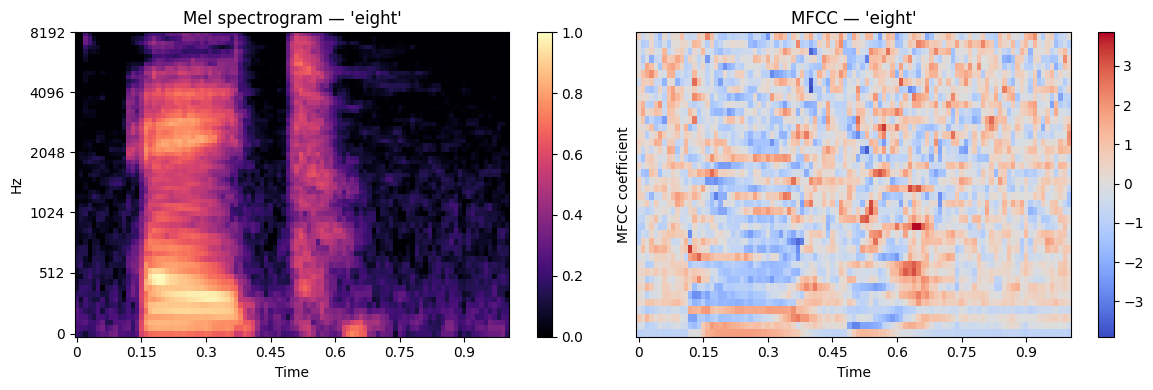

In [40]:
sample = dataset_digits["train"][0]
word = label_names[sample["label"]]

# Test wrapper — confirms remapping works
mel_features, label = preprocess_for_training(sample, use_mfcc=False)
mfcc_features, _ = preprocess_for_training(sample, use_mfcc=True)

print(f"Word: '{word}'")
print(f"Mel shape:  {mel_features.shape}")    # (64, 101, 1)
print(f"MFCC shape: {mfcc_features.shape}")   # (40, 101, 1)
print(f"Label: {label} = '{idx_to_digit[label]}'")  
print(f"Mel value range:  min={mel_features.min():.3f}  max={mel_features.max():.3f}")
print(f"MFCC value range: min={mfcc_features.min():.3f}  max={mfcc_features.max():.3f}")

# Visualize both side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

img1 = librosa.display.specshow(
    mel_features[:, :, 0],
    sr=16000, hop_length=160,
    x_axis='time', y_axis='mel',
    ax=axes[0]
)
axes[0].set_title(f"Mel spectrogram — '{word}'")
fig.colorbar(img1, ax=axes[0])

img2 = librosa.display.specshow(
    mfcc_features[:, :, 0],
    sr=16000, hop_length=160,
    x_axis='time',
    ax=axes[1]
)
axes[1].set_title(f"MFCC — '{word}'")
axes[1].set_ylabel("MFCC coefficient")
fig.colorbar(img2, ax=axes[1])

plt.tight_layout()
plt.savefig("mel_vs_mfcc.png")
plt.show()

In [41]:
print("=" * 50)
print("VERIFICATION BEFORE BUILDING DATASET")
print("=" * 50)

# 1. Check filtered dataset has only digits
print("\n1. FILTERED DATASET SIZES:")
print(f"   Train:      {len(dataset_digits['train'])} examples")
print(f"   Validation: {len(dataset_digits['validation'])} examples")
print(f"   Test:       {len(dataset_digits['test'])} examples")

# 2. Check only digit labels exist in filtered dataset
print("\n2. LABEL CHECK — should only see 10-19:")
train_labels = set(dataset_digits["train"]["label"])
print(f"   Unique labels in train: {sorted(train_labels)}")
print(f"   Expected:               {sorted(digit_ids)}")
print(f"   Match: {train_labels == digit_ids}")

# 3. Check remapping covers all labels in dataset
print("\n3. REMAPPING CHECK:")
all_labels_in_dataset = (
    set(dataset_digits["train"]["label"]) |
    set(dataset_digits["validation"]["label"]) |
    set(dataset_digits["test"]["label"])
)
unmapped = all_labels_in_dataset - set(digit_to_idx.keys())
print(f"   Labels in dataset:    {sorted(all_labels_in_dataset)}")
print(f"   Labels in digit_to_idx: {sorted(digit_to_idx.keys())}")
print(f"   Unmapped labels:      {unmapped} (should be empty set())")

# 4. Check preprocess_for_training on one sample from each split
print("\n4. PREPROCESSING CHECK — one sample per split:")
for split_name in ["train", "validation", "test"]:
    sample = dataset_digits[split_name][0]
    mel_features, label = preprocess_for_training(sample, use_mfcc=False)
    mfcc_features, label2 = preprocess_for_training(sample, use_mfcc=True)
    word = idx_to_digit[label]
    
    print(f"\n   [{split_name}]")
    print(f"   Original label: {sample['label']} ({label_names[sample['label']]})")
    print(f"   Model label:    {label} ({word})")
    print(f"   Labels match:   {label == label2}")
    print(f"   Mel shape:      {mel_features.shape} (expected (64, 101, 1))")
    print(f"   MFCC shape:     {mfcc_features.shape} (expected (40, 101, 1))")
    print(f"   Mel range:      {mel_features.min():.3f} to {mel_features.max():.3f} (expected 0.0 to 1.0)")

# 5. Check class balance in filtered training set
print("\n5. CLASS BALANCE — examples per digit:")
import collections
counts = collections.Counter(dataset_digits["train"]["label"])
for original_id in sorted(counts.keys()):
    model_id = digit_to_idx[original_id]
    word = idx_to_digit[model_id]
    bar = "█" * (counts[original_id] // 100)
    print(f"   {word:<8} (model label {model_id}): {counts[original_id]:>5} examples  {bar}")

# 6. Quick timing estimate
print("\n6. TIMING ESTIMATE:")
import time
start = time.time()
for example in list(dataset_digits["train"])[:100]:
    preprocess_for_training(example, use_mfcc=False)
elapsed = time.time() - start
per_example = elapsed / 100
total_examples = (
    len(dataset_digits["train"]) +
    len(dataset_digits["validation"]) +
    len(dataset_digits["test"])
) * 2  # x2 because mel AND mfcc
estimated_minutes = (per_example * total_examples) / 60
print(f"   100 examples took:    {elapsed:.2f} seconds")
print(f"   Per example:          {per_example*1000:.1f} ms")
print(f"   Estimated total time: {estimated_minutes:.1f} minutes")

print("\n" + "=" * 50)
print("ALL CHECKS PASSED — SAFE TO BUILD DATASET")
print("=" * 50)

VERIFICATION BEFORE BUILDING DATASET

1. FILTERED DATASET SIZES:
   Train:      18620 examples
   Validation: 2494 examples
   Test:       160 examples

2. LABEL CHECK — should only see 10-19:
   Unique labels in train: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
   Expected:               [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
   Match: True

3. REMAPPING CHECK:
   Labels in dataset:    [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
   Labels in digit_to_idx: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
   Unmapped labels:      set() (should be empty set())

4. PREPROCESSING CHECK — one sample per split:

   [train]
   Original label: 18 (eight)
   Model label:    8 (eight)
   Labels match:   True
   Mel shape:      (64, 101, 1) (expected (64, 101, 1))
   MFCC shape:     (40, 101, 1) (expected (40, 101, 1))
   Mel range:      0.000 to 1.000 (expected 0.0 to 1.0)

   [validation]
   Original label: 18 (eight)
   Model label:    8 (eight)
   Labels match:   True
   Mel shape:      (64, 101, 1) (ex

In [42]:
def build_dataset(hf_dataset, use_mfcc=False):
    X, y = [], []
    for example in tqdm(hf_dataset):
        features, label = preprocess_for_training(example, use_mfcc=use_mfcc)
        X.append(features)
        y.append(label)
    return np.array(X), np.array(y)

print("Building mel training data...")
X_train_mel, y_train = build_dataset(dataset_digits["train"], use_mfcc=False)
print(f"X_train_mel: {X_train_mel.shape}, y_train: {y_train.shape}")

print("Building mel validation data...")
X_val_mel, y_val = build_dataset(dataset_digits["validation"], use_mfcc=False)
print(f"X_val_mel: {X_val_mel.shape}, y_val: {y_val.shape}")

print("Building mel test data...")
X_test_mel, y_test = build_dataset(dataset_digits["test"], use_mfcc=False)
print(f"X_test_mel: {X_test_mel.shape}, y_test: {y_test.shape}")

print("Building mfcc training data...")
X_train_mfcc, _ = build_dataset(dataset_digits["train"], use_mfcc=True)
print(f"X_train_mfcc: {X_train_mfcc.shape}")

print("Building mfcc validation data...")
X_val_mfcc, _ = build_dataset(dataset_digits["validation"], use_mfcc=True)
print(f"X_val_mfcc: {X_val_mfcc.shape}")

print("Building mfcc test data...")
X_test_mfcc, _ = build_dataset(dataset_digits["test"], use_mfcc=True)
print(f"X_test_mfcc: {X_test_mfcc.shape}")

Building mel training data...


100%|██████████| 18620/18620 [00:16<00:00, 1131.98it/s]


X_train_mel: (18620, 64, 101, 1), y_train: (18620,)
Building mel validation data...


100%|██████████| 2494/2494 [00:01<00:00, 1486.33it/s]


X_val_mel: (2494, 64, 101, 1), y_val: (2494,)
Building mel test data...


...

X_train_mfcc: (18620, 40, 101, 1)
Building mfcc validation data...


100%|██████████| 2494/2494 [00:02<00:00, 1187.27it/s]


X_val_mfcc: (2494, 40, 101, 1)
Building mfcc test data...


100%|██████████| 160/160 [00:00<00:00, 1196.13it/s]

X_test_mfcc: (160, 40, 101, 1)


In [ ]:
os.makedirs(DATA_DIR, exist_ok=True)

np.save(os.path.join(DATA_DIR, "X_train_mel.npy"), X_train_mel)
np.save(os.path.join(DATA_DIR, "X_val_mel.npy"), X_val_mel)
np.save(os.path.join(DATA_DIR, "X_test_mel.npy"), X_test_mel)
np.save(os.path.join(DATA_DIR,"X_train_mfcc.npy"), X_train_mfcc)
np.save(os.path.join(DATA_DIR, "X_val_mfcc.npy"), X_val_mfcc)
np.save(os.path.join(DATA_DIR, "X_test_mfcc.npy"), X_test_mfcc)
np.save(os.path.join(DATA_DIR, "y_train.npy"), y_train)
np.save(os.path.join(DATA_DIR, "y_val.npy"), y_val)
np.save(os.path.join(DATA_DIR, "y_test.npy"), y_test)

print("All arrays saved to disk")

In [51]:
from src.augmentation import augment_audio, sample_silence_window, spec_augment

def build_augmented_training_set(dataset_train, noise_clips, 
                                   augment_factor=2,
                                   n_silence_samples=1800):
    """
    Build training set with:
    - Original digit examples
    - Augmented digit examples (augment_factor-1 copies per original)
    - Silence samples generated from long silence clips
    """
    X, y = [], []
    
    print(f"Processing {len(dataset_train)} digit examples...")
    for example in tqdm(dataset_train):
        # Skip silence — we generate those separately with proper sampling
        if example["label"] == silence_original_id:
            continue
        
        audio = np.array(example["audio"]["array"], dtype=np.float32)
        # Pad/truncate
        if len(audio) < 16000:
            audio = np.pad(audio, (0, 16000 - len(audio)))
        else:
            audio = audio[:16000]
        
        label = digit_to_idx_11[example["label"]]
        
        # Original (no augmentation)
        mel = audio_to_mel_from_array(audio)
        X.append(mel)
        y.append(label)
        
        # Augmented copies
        for _ in range(augment_factor - 1):
            aug_audio = augment_audio(audio.copy(), noise_clips=noise_clips)
            mel_aug = audio_to_mel_from_array(aug_audio)
            # Apply SpecAugment on top
            mel_aug = spec_augment(mel_aug)
            X.append(mel_aug)
            y.append(label)
    
    # Generate silence training samples from long clips
    print(f"Generating {n_silence_samples} silence samples...")
    silence_label = digit_to_idx_11[silence_original_id]  # class 10
    for _ in tqdm(range(n_silence_samples)):
        clip = noise_clips[np.random.randint(len(noise_clips))]
        silence_audio = sample_silence_window(clip)
        mel = audio_to_mel_from_array(silence_audio)
        X.append(mel)
        y.append(silence_label)
    
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


def audio_to_mel_from_array(audio, sr=16000):
    """Like audio_to_mel but takes raw numpy array directly"""
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=64, n_fft=400, hop_length=160
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    return mel_norm[..., np.newaxis]


# Build augmented training set
X_train_aug, y_train_aug = build_augmented_training_set(
    dataset_digits["train"],
    noise_clips=silence_clips_train,
    augment_factor=2,
    n_silence_samples=1800
)

print(f"\nAugmented training set shape: {X_train_aug.shape}")
print(f"Augmented labels shape:       {y_train_aug.shape}")

# Save with NEW filenames so baseline stays intact
np.save(os.path.join(DATA_DIR, "X_train_mel_aug11.npy"), X_train_aug)
np.save(os.path.join(DATA_DIR, "y_train_aug11.npy"), y_train_aug)

Processing 18620 digit examples...


100%|██████████| 18620/18620 [00:24<00:00, 772.29it/s]


Generating 1800 silence samples...


100%|██████████| 1800/1800 [00:00<00:00, 2024.54it/s]



Augmented training set shape: (39040, 64, 101, 1)
Augmented labels shape:       (39040,)


In [ ]:
def build_clean_11class_set(dataset_split, noise_clips, n_silence_samples):
    X, y = [], []
    silence_label = digit_to_idx_11[silence_original_id]
    
    for example in tqdm(dataset_split):
        orig_label = example["label"]
        
        # Only keep digits and silence
        if orig_label not in digit_to_idx_11:
            continue
        
        audio = np.array(example["audio"]["array"], dtype=np.float32)
        if len(audio) < 16000:
            audio = np.pad(audio, (0, 16000 - len(audio)))
        else:
            audio = audio[:16000]
        
        mel = audio_to_mel_from_array(audio)
        X.append(mel)
        y.append(digit_to_idx_11[orig_label])
    
   
    n_existing_silence = sum(1 for label in y if label == silence_label)
    n_to_generate = max(0, n_silence_samples - n_existing_silence)
    
    for _ in range(n_to_generate):
        clip = noise_clips[np.random.randint(len(noise_clips))]
        silence_audio = sample_silence_window(clip)
        mel = audio_to_mel_from_array(silence_audio)
        X.append(mel)
        y.append(silence_label)
    
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


# Validation — real silence + generate extras to reach target
print("Building 11-class validation set...")
X_val_11, y_val_11 = build_clean_11class_set(
    dataset["validation"],
    noise_clips=silence_clips_val,
    n_silence_samples=240
)
print(f"Validation 11-class: {X_val_11.shape}")
print(f"  Silence count: {(y_val_11 == 10).sum()}")


print("Building 11-class test set...")
X_test_11, y_test_11 = build_clean_11class_set(
    dataset["test"],
    noise_clips=silence_clips_test,
    n_silence_samples=0  
)
print(f"Test 11-class: {X_test_11.shape}")
print(f"  Silence count: {(y_test_11 == 10).sum()}")


np.save(os.path.join(DATA_DIR, "X_val_mel_11class.npy"), X_val_11)
np.save(os.path.join(DATA_DIR, "y_val_11class.npy"), y_val_11)
np.save(os.path.join(DATA_DIR, "X_test_mel_11class.npy"), X_test_11)
np.save(os.path.join(DATA_DIR, "y_test_11class.npy"), y_test_11)

print("\nAll 11-class arrays saved.")

Building 11-class validation set...


100%|██████████| 6799/6799 [00:02<00:00, 2891.08it/s]


Validation 11-class: (2734, 64, 101, 1)
  Silence count: 240
Building 11-class test set...


100%|██████████| 3081/3081 [00:00<00:00, 4916.56it/s]

Test 11-class: (417, 64, 101, 1)
  Silence count: 257

All 11-class arrays saved.


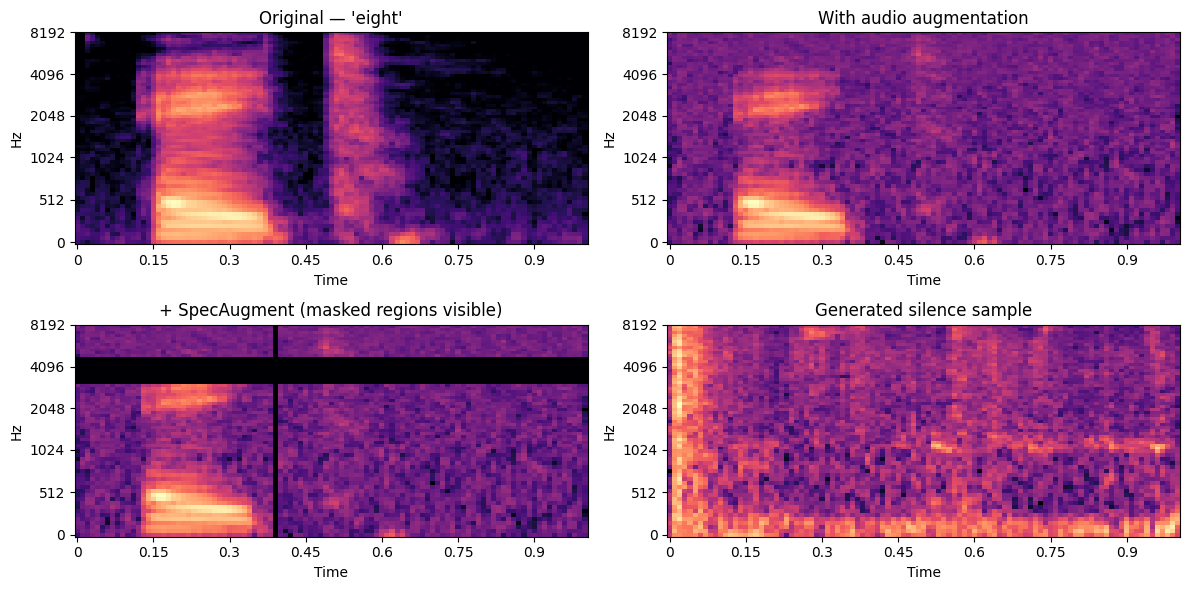

Original 'eight':


With augmentation (time shift, volume, noise):


Pure silence sample:


In [ ]:

import IPython.display as ipd


example = None
for ex in dataset_digits["train"]:
    if ex["label"] != silence_original_id:
        example = ex
        break

audio = np.array(example["audio"]["array"], dtype=np.float32)
if len(audio) < 16000:
    audio = np.pad(audio, (0, 16000 - len(audio)))
word = label_names[example["label"]]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))


mel_orig = audio_to_mel_from_array(audio)
librosa.display.specshow(mel_orig[:, :, 0], sr=16000, hop_length=160,
                          x_axis='time', y_axis='mel', ax=axes[0, 0])
axes[0, 0].set_title(f"Original — '{word}'")


aug1 = augment_audio(audio.copy(), noise_clips=silence_clips_train)
mel_aug1 = audio_to_mel_from_array(aug1)
librosa.display.specshow(mel_aug1[:, :, 0], sr=16000, hop_length=160,
                          x_axis='time', y_axis='mel', ax=axes[0, 1])
axes[0, 1].set_title("With audio augmentation")


mel_spec_aug = spec_augment(mel_aug1)
librosa.display.specshow(mel_spec_aug[:, :, 0], sr=16000, hop_length=160,
                          x_axis='time', y_axis='mel', ax=axes[1, 0])
axes[1, 0].set_title("+ SpecAugment (masked regions visible)")


silence_sample = sample_silence_window(silence_clips_train[0])
mel_silence = audio_to_mel_from_array(silence_sample)
librosa.display.specshow(mel_silence[:, :, 0], sr=16000, hop_length=160,
                          x_axis='time', y_axis='mel', ax=axes[1, 1])
axes[1, 1].set_title("Generated silence sample")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "augmentation_examples.png"))
plt.show()


print(f"Original '{word}':")
ipd.display(ipd.Audio(audio, rate=16000))
print("With augmentation (time shift, volume, noise):")
ipd.display(ipd.Audio(aug1, rate=16000))
print("Pure silence sample:")
ipd.display(ipd.Audio(silence_sample, rate=16000))

In [48]:
print("VERIFICATION")
print("=" * 50)

# Baseline files (10-class) should be unchanged
X_train_mel = np.load(os.path.join(DATA_DIR, "X_train_mel.npy"))
y_train = np.load(os.path.join(DATA_DIR, "y_train.npy"))
print(f"Baseline 10-class:")
print(f"  X_train shape: {X_train_mel.shape}")
print(f"  y_train unique: {sorted(set(y_train))}")  # should be [0..9]

# Augmented files should be 11-class
X_train_aug = np.load(os.path.join(DATA_DIR, "X_train_mel_aug11.npy"))
y_train_aug = np.load(os.path.join(DATA_DIR, "y_train_aug11.npy"))
print(f"\nAugmented 11-class:")
print(f"  X_train_aug shape: {X_train_aug.shape}")
print(f"  y_train_aug unique: {sorted(set(y_train_aug))}")  # should be [0..10]

# Class balance in augmented
print(f"  Silence count: {(y_train_aug == 10).sum()} (should be ~1800)")

VERIFICATION
Baseline 10-class:
  X_train shape: (18620, 64, 101, 1)
  y_train unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Augmented 11-class:
  X_train_aug shape: (39040, 64, 101, 1)
  y_train_aug unique: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10)]
  Silence count: 1800 (should be ~1800)


In [50]:
print("11-CLASS DATA VERIFICATION")
print("=" * 50)

import collections

print(f"\nTraining class distribution:")
for class_id, count in sorted(collections.Counter(y_train_aug).items()):
    print(f"  {class_id} ({idx_to_digit_11[class_id]}): {count}")

print(f"\nValidation class distribution:")
for class_id, count in sorted(collections.Counter(y_val_11).items()):
    print(f"  {class_id} ({idx_to_digit_11[class_id]}): {count}")

print(f"\nTest class distribution:")
for class_id, count in sorted(collections.Counter(y_test_11).items()):
    print(f"  {class_id} ({idx_to_digit_11[class_id]}): {count}")

11-CLASS DATA VERIFICATION

Training class distribution:
  0 (zero): 3732
  1 (one): 3784
  2 (two): 3746
  3 (three): 3682
  4 (four): 3678
  5 (five): 3688
  6 (six): 3726
  7 (seven): 3750
  8 (eight): 3704
  9 (nine): 3750
  10 (_silence_): 1800

Validation class distribution:
  0 (zero): 260
  1 (one): 230
  2 (two): 236
  3 (three): 248
  4 (four): 280
  5 (five): 242
  6 (six): 262
  7 (seven): 263
  8 (eight): 243
  9 (nine): 230
  10 (_silence_): 240

Test class distribution:
  0 (zero): 13
  1 (one): 16
  2 (two): 16
  3 (three): 15
  4 (four): 9
  5 (five): 23
  6 (six): 11
  7 (seven): 16
  8 (eight): 16
  9 (nine): 25
  10 (_silence_): 257
